In [1]:
# Enable automatic reloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp

# Import from the engine
from l_vqe_engine import (
    build_maxcut_hamiltonian,
    best_known_maxcut_cost,
    simulate_one_lvqe
)

=== 1. MAX-CUT GRAPH SETUP & BASELINE ===


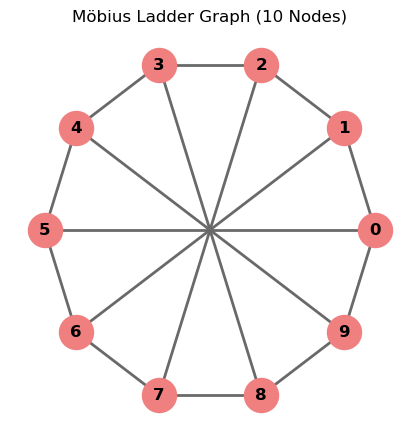

Calculating exact classical baseline...
True Maximum Cut (Negative Cost): -15.00
Total Qubits Required: 10


In [6]:
print("=== 1. MAX-CUT GRAPH SETUP & BASELINE ===")

def generate_mobius_ladder(n_nodes):
    """Generates a Möbius Ladder graph of n_nodes (must be even)."""
    assert n_nodes % 2 == 0, "Möbius ladder requires an even number of nodes."
    # Start with a standard ring (cycle graph)
    G = nx.cycle_graph(n_nodes)
    # Add the "rungs" across the opposite sides of the circle
    half = n_nodes // 2
    for i in range(half):
        G.add_edge(i, i + half)
    return G

# Generate the 10-node Möbius Ladder
n_nodes = 10
G_maxcut = generate_mobius_ladder(n_nodes)

# Visualize it
plt.figure(figsize=(4, 4))
pos = nx.circular_layout(G_maxcut) # Circular layout shows the cross-rungs beautifully
nx.draw(
    G_maxcut, 
    pos, 
    with_labels=True, 
    node_color='lightcoral', 
    edge_color='dimgray',
    width=2.0,
    font_weight='bold',
    node_size=600
)
plt.title(f"Möbius Ladder Graph ({n_nodes} Nodes)")
plt.show()

# Calculate absolute true baseline
print("Calculating exact classical baseline...")
true_maxcut_val = best_known_maxcut_cost(G_maxcut)
print(f"True Maximum Cut (Negative Cost): {true_maxcut_val:.2f}")
print(f"Total Qubits Required: {n_nodes}")

In [10]:
print("\n=== 2. L-VQE EXECUTION (SMO MAX-CUT) ===")

H_mc = build_maxcut_hamiltonian(G_maxcut)
rng_mc = np.random.default_rng(101)

# Run SMO
smo_res = simulate_one_lvqe(
    n_q=n_nodes,
    H=H_mc,
    max_layers=2,
    shots=None,
    max_iter_per_layer=600,
    rng=rng_mc,
    optimizer="SMO"
)

rho_smo = smo_res['final_cost'] / true_maxcut_val

print(f"\nSMO Final Cost: {smo_res['final_cost']:.4f}")
print(f"SMO Approximation Ratio (ρ): {rho_smo:.4f}")


=== 2. L-VQE EXECUTION (SMO MAX-CUT) ===
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -15.000000
  Layer 2  (82 params) ... cost = -15.000000

SMO Final Cost: -15.0000
SMO Approximation Ratio (ρ): 1.0000


In [12]:
print("\n=== 2. L-VQE EXECUTION (COBYLA MAX-CUT) ===")

H_mc = build_maxcut_hamiltonian(G_maxcut)
rng_mc = np.random.default_rng(101)

# Run SMO
cobyla_res = simulate_one_lvqe(
    n_q=n_nodes,
    H=H_mc,
    max_layers=2,
    shots=None,
    max_iter_per_layer=600,
    rng=rng_mc,
    optimizer="COBYLA"
)

rho_cobyla = cobyla_res['final_cost'] / true_maxcut_val

print(f"\nCOBYLA Final Cost: {cobyla_res['final_cost']:.4f}")
print(f"COBYLA Approximation Ratio (ρ): {rho_cobyla:.4f}")


=== 2. L-VQE EXECUTION (COBYLA MAX-CUT) ===
  Layer 0  (10 params) ... cost = -15.000000
  Layer 1  (46 params) ... cost = -15.000000
  Layer 2  (82 params) ... cost = -15.000000

COBYLA Final Cost: -15.0000
COBYLA Approximation Ratio (ρ): 1.0000



=== 3. OPTIMIZER TRAJECTORY COMPARISON (MAX-CUT) ===


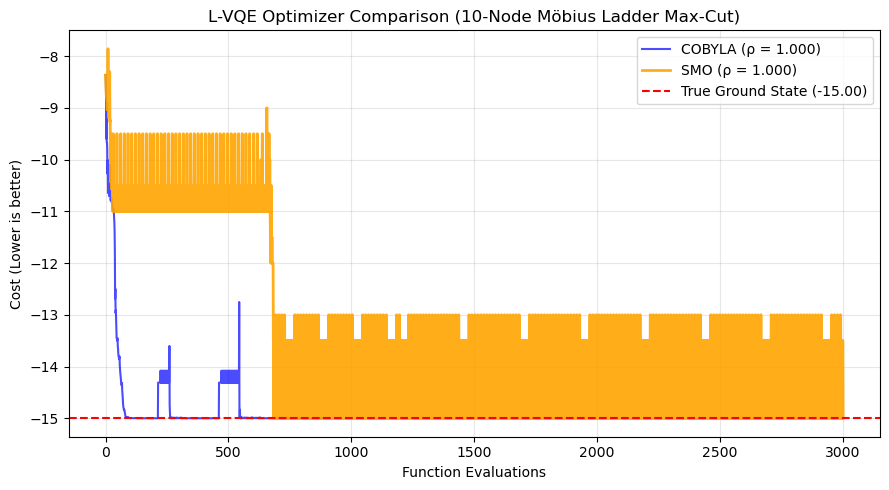

In [13]:
print("\n=== 3. OPTIMIZER TRAJECTORY COMPARISON (MAX-CUT) ===")
plt.figure(figsize=(9, 5))

# We plot the absolute cost (negative values) because we are directly minimizing the Max-Cut Hamiltonian
plt.plot(cobyla_res["cost_history"], label=f"COBYLA (ρ = {rho_cobyla:.3f})", color='blue', alpha=0.7)
plt.plot(smo_res["cost_history"], label=f"SMO (ρ = {rho_mc:.3f})", color='orange', alpha=0.9, linewidth=2)

# Plot the absolute classical ceiling (the lowest possible negative cost)
plt.axhline(true_maxcut_val, color="red", linestyle="--", linewidth=1.5, label=f"True Ground State ({true_maxcut_val:.2f})")

plt.title("L-VQE Optimizer Comparison (10-Node Möbius Ladder Max-Cut)")
plt.xlabel("Function Evaluations")
plt.ylabel("Cost (Lower is better)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
import time
import pandas as pd
import numpy as np
import networkx as nx

# Import from your engine
from l_vqe_engine import (
    build_maxcut_hamiltonian,
    best_known_maxcut_cost,
    simulate_one_lvqe,
    simulate_one_qaoa
)

print("=== 4. STARTING MAX-CUT BATCH ANALYSIS ===")

# --- Configuration ---
# We can push to 14 nodes because Max-Cut only uses 1 qubit per node
graph_sizes = [8, 10, 12, 14] 
n_seeds = 10
device = "lightning.qubit"  

# Budgets
lvqe_evals_per_layer = 600  
qaoa_evals = 3000           
qaoa_p_values = [1, 5, 10]  # Condensed p-values

results_data = []

for n_nodes in graph_sizes:
    print(f"\n--- Processing 3-Regular Graph: {n_nodes} Nodes ---")
    
    # Generate a random 3-regular graph (standard Max-Cut benchmark)
    G = nx.random_regular_graph(d=3, n=n_nodes, seed=42)
    n_q = n_nodes # 1 Qubit per node!
    
    print(f"Calculating true baseline for {n_nodes} nodes...")
    true_baseline = best_known_maxcut_cost(G)
    print('True Baseline:',true_baseline)
    H_mc = build_maxcut_hamiltonian(G)
    
    for seed in range(n_seeds):
        print(f"  Running Seed {seed+1}/{n_seeds}...")
        rng = np.random.default_rng(seed)
        
        # --- A. L-VQE (SMO) ---
        print('L-VQE(SMO):')
        t0 = time.time()
        res_smo = simulate_one_lvqe(
            n_q, H_mc, max_layers=2, shots=None, 
            max_iter_per_layer=lvqe_evals_per_layer, 
            rng=rng, device_name=device, optimizer="SMO"
        )
        rho_smo = res_smo['final_cost'] / true_baseline
        results_data.append({"Algorithm": "L-VQE (SMO)", "Nodes": n_nodes, "Seed": seed, "p_or_L": 2, "Rho": rho_smo, "Time_s": time.time()-t0})

        # --- B. L-VQE (COBYLA) ---
        print('L-VQE(COBYLA):')
        t0 = time.time()
        res_cobyla = simulate_one_lvqe(
            n_q, H_mc, max_layers=2, shots=None, 
            max_iter_per_layer=lvqe_evals_per_layer, 
            rng=rng, device_name=device, optimizer="COBYLA"
        )
        rho_cobyla = res_cobyla['final_cost'] / true_baseline
        results_data.append({"Algorithm": "L-VQE (COBYLA)", "Nodes": n_nodes, "Seed": seed, "p_or_L": 2, "Rho": rho_cobyla, "Time_s": time.time()-t0})

        # --- C. QAOA ---
        print('QAOA:')
        for p in qaoa_p_values:
            print('p =',p)
            t0 = time.time()
            res_qaoa = simulate_one_qaoa(
                n_q, H_mc, p_steps=p, shots=None, 
                max_evals=qaoa_evals, rng=rng, device_name=device
            )
            rho_qaoa = res_qaoa['final_cost'] / true_baseline
            results_data.append({"Algorithm": "QAOA", "Nodes": n_nodes, "Seed": seed, "p_or_L": p, "Rho": rho_qaoa, "Time_s": time.time()-t0})

# --- Compile and Export ---
print("\n=== ANALYSIS COMPLETE. COMPILING DATA ===")
df_results = pd.DataFrame(results_data)
csv_filename = "data_maxcut_benchmark.csv"
df_results.to_csv(csv_filename, index=False)
print(f"Data successfully exported to '{csv_filename}'.")

=== 4. STARTING MAX-CUT BATCH ANALYSIS ===

--- Processing 3-Regular Graph: 8 Nodes ---
Calculating true baseline for 8 nodes...
True Baseline: -10.0
  Running Seed 1/10...
L-VQE(SMO):
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -10.000000
  Layer 2  (64 params) ... cost = -10.000000
L-VQE(COBYLA):
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -10.000000
  Layer 2  (64 params) ... cost = -10.000000
QAOA:
p = 1
p = 5
p = 10
  Running Seed 2/10...
L-VQE(SMO):
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -10.000000
  Layer 2  (64 params) ... cost = -10.000000
L-VQE(COBYLA):
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -10.000000
  Layer 2  (64 params) ... cost = -10.000000
QAOA:
p = 1
p = 5
p = 10
  Running Seed 3/10...
L-VQE(SMO):
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -10.000000
  Layer 2  (64 params) ... cost = -10.00

=== 5. GENERATING MAX-CUT BENCHMARK PLOT ===


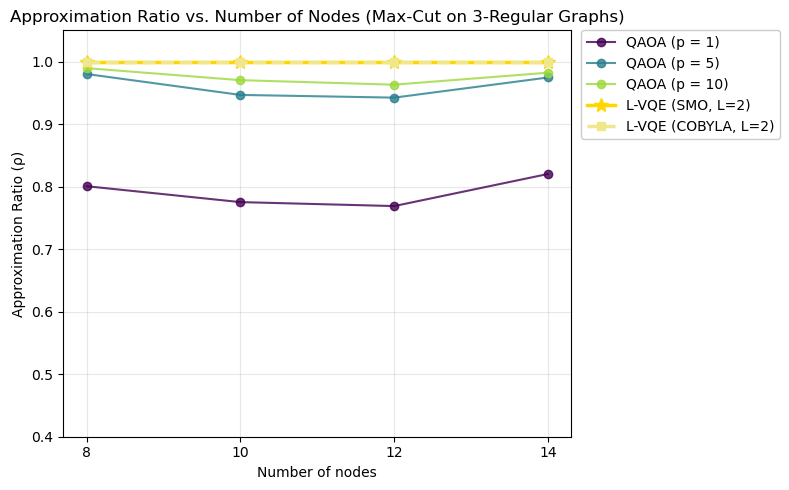

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

print("=== 5. GENERATING MAX-CUT BENCHMARK PLOT ===")

# 1. Load the exported Max-Cut batch data
csv_filename = "data_maxcut_benchmark.csv"
df = pd.read_csv(csv_filename)

# 2. Extract the BEST approximation ratio found across the 10 seeds
df_best = df.groupby(['Algorithm', 'Nodes', 'p_or_L'])['Rho'].max().reset_index()

plt.figure(figsize=(8, 5))

# 3. Plot QAOA (Gradient mapping for p=1, 5, 10)
qaoa_data = df_best[df_best['Algorithm'] == 'QAOA']
p_values = sorted(qaoa_data['p_or_L'].unique())

# Using viridis to maintain visual consistency
colors = cm.viridis(np.linspace(0, 0.85, len(p_values)))

for p, color in zip(p_values, colors):
    subset = qaoa_data[qaoa_data['p_or_L'] == p]
    plt.plot(
        subset['Nodes'], subset['Rho'], 
        marker='o', markersize=6, 
        color=color, alpha=0.8, 
        label=f'QAOA (p = {p})'
    )

# 4. Plot L-VQE (Bold, distinct lines)
lvqe_smo = df_best[df_best['Algorithm'] == 'L-VQE (SMO)']
plt.plot(
    lvqe_smo['Nodes'], lvqe_smo['Rho'], 
    marker='*', markersize=10, 
    color='gold', linewidth=2.5, 
    label='L-VQE (SMO, L=2)'
)

lvqe_cobyla = df_best[df_best['Algorithm'] == 'L-VQE (COBYLA)']
plt.plot(
    lvqe_cobyla['Nodes'], lvqe_cobyla['Rho'], 
    marker='s', markersize=6, 
    color='khaki', linewidth=2.5, linestyle='--', 
    label='L-VQE (COBYLA, L=2)'
)

# 5. Formatting
plt.title("Approximation Ratio vs. Number of Nodes (Max-Cut on 3-Regular Graphs)")
plt.xlabel("Number of nodes")
plt.ylabel("Approximation Ratio (ρ)")

# Lock the ticks to the even node sizes used in the Max-Cut experiment
plt.xticks([8, 10, 12, 14])

# Adjust Y-limits. Max-Cut typically has a higher floor than community detection, 
# but keeping it 0.4 to 1.05 frames the top-tier performance nicely.
plt.ylim(0.4, 1.05) 

# Force the legend outside the plot area
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, framealpha=1.0)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()